# 05 — Computing 2-D radiative quantities from a MAJA output

This notebook shows how to derive spatially-varying radiative quantities from a
real Sentinel-2 L2A product processed by the **MAJA** atmospheric processor.

The key difference from notebook 03 is that all atmospheric and geometric
parameters ($AOT$, $h$, $h_{ref}$, SZA, VZA, …) come directly from the
product metadata rather than being set manually.  The convenience function
`config_from_scene` reads these variables from the loaded `ImageDict` and
assembles the `AtmoConfig` / `GeoConfig` / `SpectralConfig` bundle automatically.

**Workflow**

```
gaussian_image_dict()   # synthetic surface (spatial support)
       ↓
  MajaLoader            # injects aot, h, rh, href, sza, vza, saa, vaa
       ↓
config_from_scene()     # builds AtmoConfig / GeoConfig / SpectralConfig
       ↓
 RadiativePipeline      # Smart-G Monte-Carlo (GPU)
       ↓
 2-D maps of tdir_down, tdir_up, tdif_down, tdif_up, rho_atm, sph_alb
```

**Requires:** a configured `SMARTG_DIR_AUXDATA` environment variable, a GPU, and
access to a MAJA L2A product folder and the corresponding DEM.

In [1]:
import os
import structlog
from pathlib import Path

import matplotlib.pyplot as plt

from adjeff.api import config_from_scene, load_maja
from adjeff.core import S2Band, gaussian_image_dict
from adjeff.modules.loaders import MajaLoader
from adjeff.modules.samplers import RadiativePipeline
from adjeff.utils import CacheStore

# Verify Smart-G is configured
assert "SMARTG_DIR_AUXDATA" in os.environ, (
    "Set SMARTG_DIR_AUXDATA to the Smart-G auxiliary data directory."
)

structlog.configure(
    processors=[
        structlog.processors.KeyValueRenderer(key_order=["event"]),
    ],
    logger_factory=structlog.PrintLoggerFactory(file=open("/dev/null", "w")),
)

## 5.1 — Load the MAJA product

We first create a synthetic Gaussian surface (`gaussian_image_dict`) that
defines the **spatial support** of the scene (resolution, size, bands).
`MajaLoader` then injects the atmospheric and geometric parameters extracted
from the product folder into each band dataset.

Adjust `PRODUCT_PATH` and `MNT_PATH` to point to your local MAJA product and DEM.

In [2]:
PRODUCT_PATH = Path(
    "/home/kwalcarius/downloads/"
    "SENTINEL2B_20180616-102816-151_L2A_T32TMR_C_V1-0/"
)
MNT_PATH = Path("/home/kwalcarius/downloads/DTM/")

BANDS = [S2Band.B02]
BAND = S2Band.B02

cache = CacheStore("/tmp/adjeff-maja-cache")

# Inject atmospheric/geometric parameters from the MAJA product
scene = load_maja(
    product_path=Path(
        "/home/kwalcarius/downloads/"
        "SENTINEL2B_20180616-102816-151_L2A_T32TMR_C_V1-0/"
    ),
    mnt_path=Path("/home/kwalcarius/downloads/DTM/"),
    bands=[S2Band.B02],
    res=0.120,
    as_map=True,
    cache=cache,
    compute_radiatives=True,
    n_bins=10,
    deduplicate_dims=["x", "y"]
)

print("Variables available for", BAND, ":")
print(list(scene[BAND].data_vars))

Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.


...

There is no current context to clear.


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Box(children=(FloatProgress(value=0.0, max=1200000000.0), Label(value='')), layout=Layout(align_items='center'…

There is no current context to clear.
Variables available for S2Band.B02 :
['rho_s', 'aot', 'h', 'tdir_down', 'tdir_up', 'sph_alb', 'tdif_up', 'tdif_down', 'rho_atm']


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## 5.2 — Inspect the loaded parameters

`aot` and `h` are 2-D maps with dimensions `(x, y)`, co-registered with the
surface reflectance grid.  Scalar quantities (`rh`, `sza`, `vza`, …) are stored
as 1-D DataArrays with a single value (one measurement per acquisition).

Scalar parameters:
  rh     = 30.000
  href   = 2.000
  sza    = 25.200
  saa    = 146.880
  vza    = 5.100
  vaa    = 105.660

Spatial parameters:
  aot   dims=['y', 'x']  min=0.0014  max=0.7450
  h     dims=['y', 'x']  min=0.0507  max=4.5366


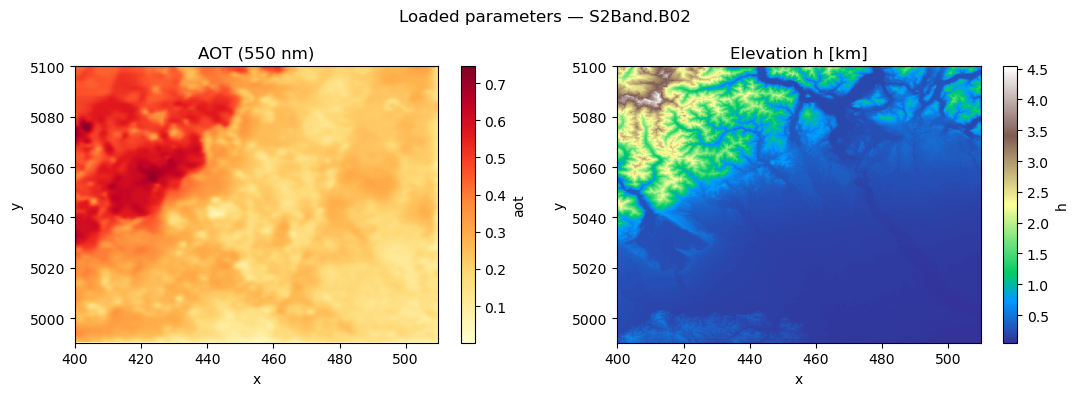

In [3]:
ds = scene[BAND]

print("Scalar parameters:")
for var in ["rh", "href", "sza", "saa", "vza", "vaa"]:
    print(f"  {var:6s} = {float(ds[var].squeeze()):.3f}")

print()
print("Spatial parameters:")
for var in ["aot", "h"]:
    da = ds[var]
    print(
        f"  {var:4s}  dims={list(da.dims)}  "
        f"min={float(da.min()):.4f}  max={float(da.max()):.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ds["aot"].plot(ax=axes[0], cmap="YlOrRd")
axes[0].set_title("AOT (550 nm)")
ds["h"].plot(ax=axes[1], cmap="terrain")
axes[1].set_title("Elevation h [km]")
plt.suptitle(f"Loaded parameters — {BAND}", fontsize=12)
plt.tight_layout()
plt.show()

## 5.3 — Build the configuration with `config_from_scene`

`config_from_scene` reads all required variables directly from the scene and
assembles the three config objects.  The `n_bins` argument **digitizes** the
continuous `aot` and `h` maps into a small set of discrete values: instead of
one Smart-G call per pixel, only `n_bins²` unique atmospheric states are
simulated, which is far more efficient.

The returned dict can be unpacked directly into `RadiativePipeline`.

In [4]:
N_BINS = 10

config = config_from_scene(scene, band=BAND, n_bins=N_BINS)

print("AtmoConfig:")
print(" ", config["atmo_config"])
print("GeoConfig:")
print(" ", config["geo_config"])
print("SpectralConfig:")
print(" ", config["spectral_config"])

AtmoConfig:
  aot=<xarray.DataArray (y: 915, x: 915)> Size: 7MB
array([[0.41451, 0.41451, 0.41451, ..., 0.16664, 0.16664, 0.00139],
       [0.41451, 0.41451, 0.41451, ..., 0.16664, 0.16664, 0.00139],
       [0.41451, 0.41451, 0.41451, ..., 0.16664, 0.16664, 0.00139],
       ...,
       [0.24926, 0.24926, 0.24926, ..., 0.08401, 0.08401, 0.00139],
       [0.24926, 0.24926, 0.24926, ..., 0.08401, 0.08401, 0.00139],
       [0.00139, 0.00139, 0.00139, ..., 0.00139, 0.00139, 0.00139]], shape=(915, 915))
Coordinates:
  * y        (y) float64 7kB 5.1e+03 5.1e+03 5.1e+03 ... 4.99e+03 4.99e+03
    index    (x, y) int64 7MB 27 27 26 26 26 26 26 26 26 ... 0 0 0 0 0 0 0 0 0
  * x        (x) float64 7kB 400.0 400.1 400.3 400.4 ... 509.3 509.5 509.6 509.7
    wl       float64 8B 490.0
Attributes:
    _adjeff_provenance:  {'module': 'MajaLoader', 'key': '433ddc9b4951ecaa02e... h=<xarray.DataArray (y: 915, x: 915)> Size: 7MB
array([[3.04131, 3.04131, 3.04131, ..., 1.04755, 1.04755, 1.04755],
       [3.

## 5.4 — Run the radiative pipeline

We pass `deduplicate_dims=["x", "y"]` so that identical atmospheric states
that appear at multiple spatial locations are collapsed into a single Smart-G
call.  Combined with the digitization above, this makes the computation
tractable on a full 915×915 scene.

Results are cached to disk so that re-running the cell skips the GPU
computation.

In [5]:
pipeline = RadiativePipeline(
    **config,
    remove_rayleigh=False,
    n_ph_rho_atm=int(1e6),
    n_ph_sph_alb=int(1e6),
    n_ph_tdif_down=int(1e6),
    n_ph_tdif_up=int(1e6),
    deduplicate_dims=["x", "y"],
    cache=cache,
)

scene = pipeline(scene)

print("Computed variables for", BAND, ":")
for var in ["tdir_down", "tdir_up", "tdif_down", "tdif_up", "rho_atm", "sph_alb"]:
    da = scene[BAND][var].compute()
    print(f"  {var:12s}  dims={list(da.dims)}")

Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.


...

There is no current context to clear.


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Box(children=(FloatProgress(value=0.0, max=60000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
Computed variables for S2Band.B02 :
  tdir_down     dims=['x', 'y', 'rh', 'href', 'sza']
  tdir_up       dims=['x', 'y', 'rh', 'href', 'vza']
  tdif_down     dims=['sza', 'x', 'y', 'rh', 'href']
  tdif_up       dims=['vza', 'x', 'y', 'rh', 'href']
  rho_atm       dims=['vza', 'sza', 'x', 'y', 'rh', 'href']
  sph_alb       dims=['x', 'y', 'rh', 'href']


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## 5.5 — Visualise the 2-D radiative maps

Each radiative quantity inherits the spatial structure of the digitized AOT
and elevation maps.  The spatial patterns in `sph_alb`, `tdif_up`, and
`tdif_down` reflect the aerosol and terrain variability across the scene.

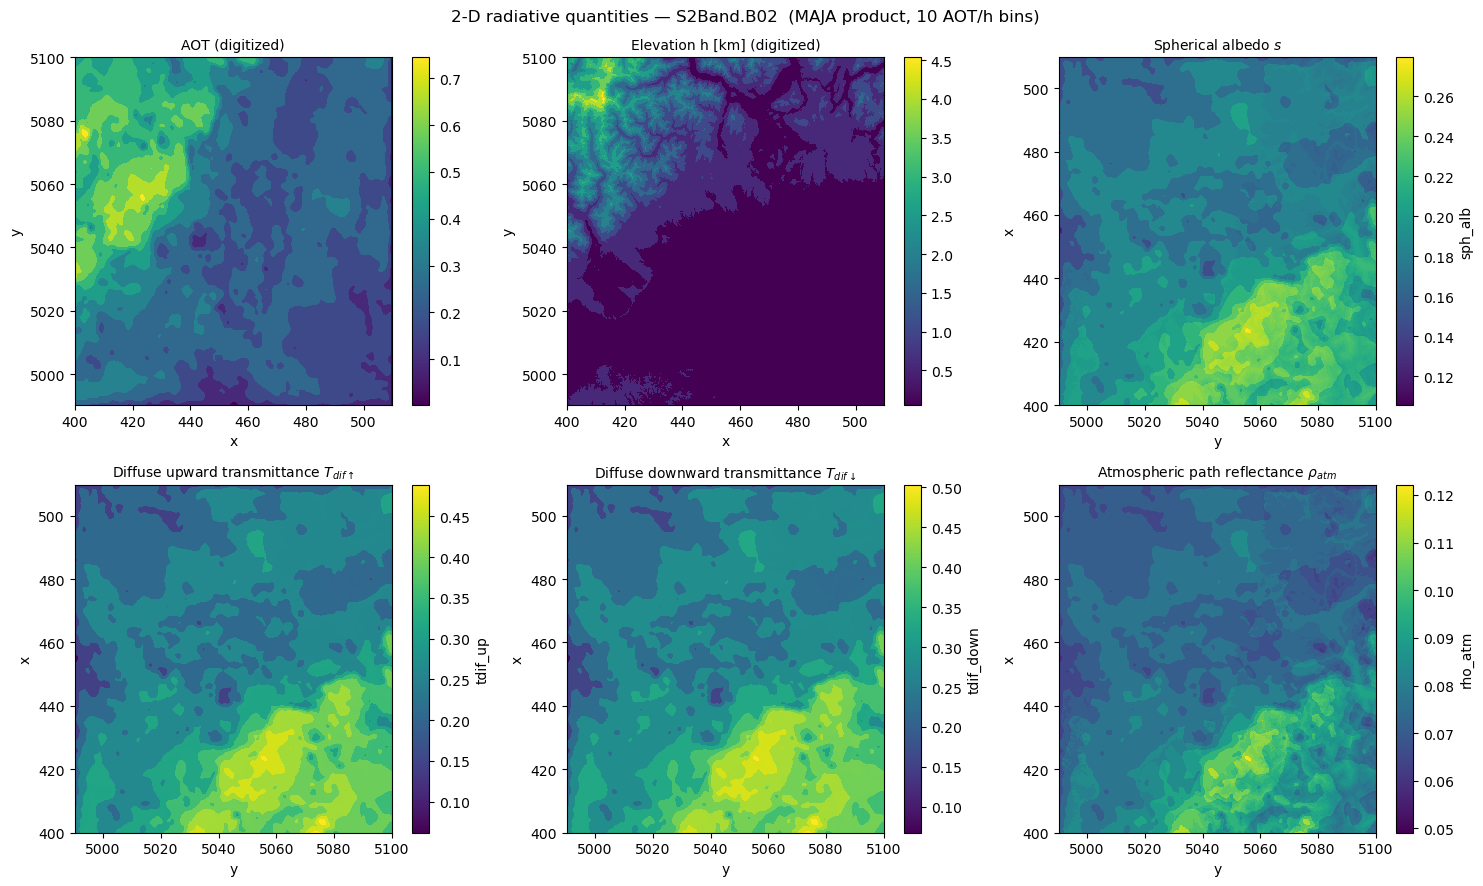

In [6]:
VARS = ["aot", "h", "sph_alb", "tdif_up", "tdif_down", "rho_atm"]
TITLES = [
    "AOT (digitized)",
    "Elevation h [km] (digitized)",
    "Spherical albedo $s$",
    "Diffuse upward transmittance $T_{dif\\uparrow}$",
    "Diffuse downward transmittance $T_{dif\\downarrow}$",
    "Atmospheric path reflectance $\\rho_{atm}$",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, var, title in zip(axes.flat, VARS, TITLES):
    da = scene[BAND][var]
    if var in ("aot", "h"):
        da = da.adjeff.digitize(n_bins=N_BINS)
    da.compute().plot(ax=ax)
    ax.set_title(title, fontsize=10)

fig.suptitle(
    f"2-D radiative quantities — {BAND}  (MAJA product, {N_BINS} AOT/h bins)",
    fontsize=12,
)
plt.tight_layout()
plt.show()